# Conception et évaluation financière d'un régime national d'assurance contre les défaillances de barrages en terre

**Étude de cas — 2025 Student Research Case Study Challenge (SOA Research Institute) — pays fictif de Tarrodan**

*Auteur : Wendlassida KABORE*

---

Ce notebook constitue la **partie actuarielle** de l'étude. Il s'appuie sur le travail
amont déjà réalisé (nettoyage, exploration, imputation des variables physiques et
prédiction par apprentissage supervisé des pertes manquantes, voir les notebooks
« Nettoyage et exploration », « Imputation » et « Analyse et ingénierie des données »).

À partir du portefeuille national de barrages en terre reconstitué et imputé, il construit :

1. la **prime pure** (espérance de perte annuelle) barrage par barrage ;
2. une **segmentation tarifaire** en classes de risque ;
3. une **simulation de Monte-Carlo** de la perte agrégée annuelle, donnant la VaR, la TVaR
   et le **capital économique** ;
4. la **tarification commerciale** (marge de risque par coût du capital, chargements) ;
5. une **projection stochastique pluriannuelle** du fonds d'assurance intégrant inflation
   et rendement financier, avec mesure de la **probabilité de ruine** ;
6. des **analyses de sensibilité** et l'évaluation de l'impact d'un **programme de prévention**.

> Toutes les pertes sont exprimées en **Qm = millions de Qums (Q)**, la monnaie de Tarrodan.

In [4]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(2025)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

# Repertoire 
DATA = "../../Données"

In [5]:
regs = ["Navaldia", "Lyndrassia", "Flumevale"]
df = pd.concat([pd.read_csv(f"{DATA}/df_{r}_imputed.csv").assign(Region=r) for r in regs],
               ignore_index=True)

df["LGF_prop"]  = df["Loss.given.failure...prop..Qm."]
df["LGF_liab"]  = df["Loss.given.failure...liab..Qm."]
df["LGF_BI"]    = df["Loss.given.failure...BI..Qm."]
df["LGF_total"] = df[["LGF_prop", "LGF_liab", "LGF_BI"]].sum(axis=1)
df["p10"] = df["Probability.of.Failure"].clip(1e-6, 0.999)

print(f"Portefeuille national : {len(df):,} barrages en terre")
df[["Region","p10","LGF_prop","LGF_liab","LGF_BI","LGF_total"]].describe().round(2)

Portefeuille national : 19,368 barrages en terre


,p10,LGF_prop,LGF_liab,LGF_BI,LGF_total
count,19368.00,19368.00,19368.00,19368.00,19368.00
mean,0.09,113.99,248.65,29.45,392.09
std,0.03,202.15,267.69,18.15,362.84
min,0.00,4.80,4.80,1.00,17.00
25%,0.08,16.00,17.60,9.40,91.75
50%,0.09,29.20,161.20,31.60,261.75
75%,0.11,45.30,400.70,44.07,600.98
max,0.20,952.70,953.90,95.40,1946.21


### Annualisation de la probabilité de défaillance et prime pure

La probabilité fournie (`Probability of Failure`) est interprétée comme une probabilité
**sur un horizon de 10 ans** En supposant un risque constant dans le temps, le taux annuel équivalent est :

$$ p_{\text{annuel}} = 1 - (1 - p_{10})^{1/10}. $$

La **prime pure** (espérance de perte annuelle) d'un barrage vaut alors :

$$ \text{EAL}_i = p_{\text{annuel},i} \times \text{LGF}_{\text{total},i}. $$

In [6]:
df["p_annual"] = 1 - (1 - df["p10"]) ** (1/10)
df["EAL"]  = df["p_annual"] * df["LGF_total"]    # prime pure annuelle
df["EL10"] = df["p10"]      * df["LGF_total"]    # perte attendue sur 10 ans

print(f"PoF moyenne 10 ans        : {df['p10'].mean():.3%}")
print(f"PoF annuelle moyenne      : {df['p_annual'].mean():.3%}")
print(f"Exposition totale (LGF)   : {df['LGF_total'].sum():>12,.0f} Qm")
print(f"Perte attendue sur 10 ans : {df['EL10'].sum():>12,.0f} Qm")
print(f"Prime pure totale (an)    : {df['EAL'].sum():>12,.0f} Qm")
print(f"Prime pure moyenne/barrage: {df['EAL'].mean():>12,.3f} Qm")

PoF moyenne 10 ans        : 9.405%
PoF annuelle moyenne      : 0.986%
Exposition totale (LGF)   :    7,594,040 Qm
Perte attendue sur 10 ans :      731,410 Qm
Prime pure totale (an)    :       76,800 Qm
Prime pure moyenne/barrage:        3.965 Qm


La perte attendue sur 10 ans (~731 000 Qm, soit ~731 milliards de Qums) est du même ordre
de grandeur que le chiffre médiatisé de l'étude de cas (pertes économiques potentielles 182 milliards USD), ce qui valide les ordres de grandeur retenus.

## 2. Profil de risque par segment

On décompose l'exposition et la prime pure selon les axes de tarification candidats :
région, niveau de danger (*Hazard*), statut réglementaire et état de l'ouvrage
(*Assessment*).

In [7]:
def seg(col):
    g = df.groupby(col).agg(n=("ID","size"), pof10=("p10","mean"),
                            lgf_mean=("LGF_total","mean"),
                            EAL=("EAL","sum"))
    g["prime_pure_moy"] = g["EAL"]/g["n"]
    g["part_EAL_%"] = 100*g["EAL"]/g["EAL"].sum()
    return g.round(3)

display(seg("Region"))
display(seg("Hazard"))
display(seg("Regulated.Dam"))

,n,pof10,lgf_mean,EAL,prime_pure_moy,part_EAL_%
Region,,,,,,
Flumevale,3074,0.087,566.928,16945.540,5.513,22.065
Lyndrassia,7920,0.095,345.030,27851.640,3.517,36.265
Navaldia,8374,0.095,372.423,32002.545,3.822,41.670


,n,pof10,lgf_mean,EAL,prime_pure_moy,part_EAL_%
Hazard,,,,,,
High,4832,0.099,770.371,38230.204,7.912,49.779
Low,12967,0.088,239.200,27771.913,2.142,36.161
Significant,1557,0.133,490.775,10720.333,6.885,13.959
Undetermined,12,0.122,480.739,77.276,6.440,0.101


,n,pof10,lgf_mean,EAL,prime_pure_moy,part_EAL_%
Regulated.Dam,,,,,,
No,8123,0.096,257.944,22086.762,2.719,28.759
Yes,11245,0.092,488.996,54712.963,4.866,71.241


On observe que les barrages **réglementés** ont une probabilité de défaillance plus faible
mais concentrent l'essentiel de la prime pure (ouvrages plus grands, exposition plus forte),
et que la prime pure croît nettement avec le niveau de danger. Flumevale, bien que comptant
le moins de barrages, présente la sévérité moyenne la plus élevée.

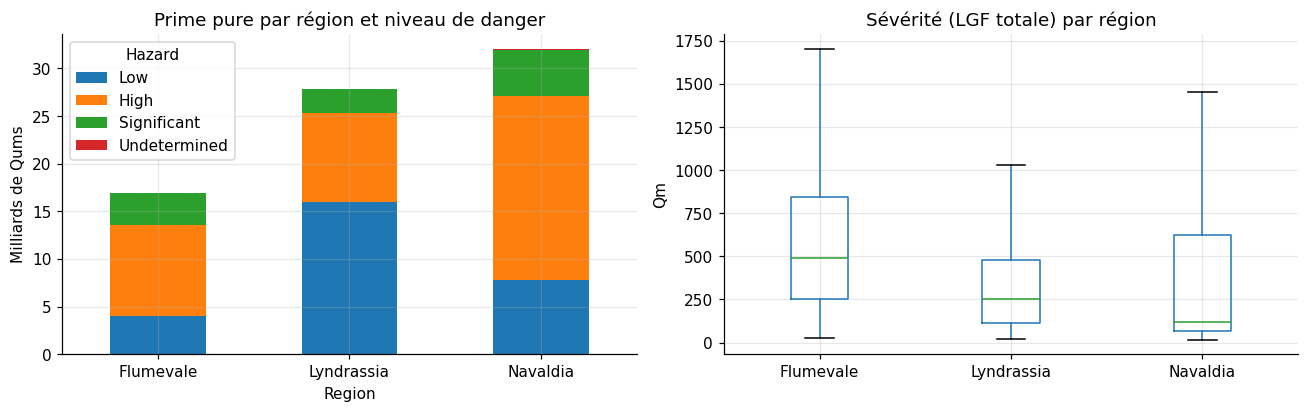

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
piv = df.pivot_table(index="Region", columns="Hazard", values="EAL", aggfunc="sum").fillna(0)/1000
piv = piv[[c for c in ["Low","High","Significant","Undetermined"] if c in piv.columns]]
piv.plot(kind="bar", stacked=True, ax=ax[0])
ax[0].set_title("Prime pure par région et niveau de danger")
ax[0].set_ylabel("Milliards de Qums"); ax[0].tick_params(axis='x', rotation=0)

df.boxplot(column="LGF_total", by="Region", ax=ax[1], showfliers=False)
ax[1].set_title("Sévérité (LGF totale) par région"); ax[1].set_ylabel("Qm")
ax[1].set_xlabel(""); plt.suptitle(""); plt.tight_layout(); plt.show()

## 3. Segmentation tarifaire en classes de risque

Pour une tarification lisible et acceptable politiquement, on regroupe les barrages en
**cinq classes de risque (A à E)**. Le score de risque combine la probabilité annuelle de
défaillance et deux modulateurs reflétant le niveau de danger et l'état de l'ouvrage :

$$ \text{score}_i = p_{\text{annuel},i}\times w^{\text{hazard}}_i \times w^{\text{état}}_i. $$

Les classes sont définies par quintiles du score.

In [9]:
haz_w = {"Low":1.0, "Undetermined":1.15, "Significant":1.35, "High":1.25}
ass_w = {"Satisfactory":0.95, "Fair":1.05, "Poor":1.20, "Unsatisfactory":1.30,
         "Not Available":1.10, "Not Rated":1.10}
df["risk_score"] = (df["p_annual"]
                    * df["Hazard"].map(haz_w).fillna(1.10)
                    * df["Assessment"].map(ass_w).fillna(1.10))
df["classe"] = pd.qcut(df["risk_score"], 5, labels=list("ABCDE"))

cls = df.groupby("classe", observed=True).agg(
    n=("ID","size"), pof_ann=("p_annual","mean"), lgf_mean=("LGF_total","mean"),
    prime_pure=("EAL","mean"), EAL=("EAL","sum"))
cls["part_n_%"]  = (100*cls["n"]/cls["n"].sum()).round(1)
cls["part_EAL_%"]= (100*cls["EAL"]/cls["EAL"].sum()).round(1)
cls.round(3)

,n,pof_ann,lgf_mean,prime_pure,EAL,part_n_%,part_EAL_%
classe,,,,,,,
A,3881,0.006,303.844,1.837,7130.037,20.0,9.3
B,3870,0.008,330.785,2.681,10376.282,20.0,13.5
C,3871,0.010,378.068,3.601,13939.063,20.0,18.1
D,3881,0.011,379.808,4.151,16111.610,20.0,21.0
E,3865,0.014,568.474,7.566,29242.733,20.0,38.1


La classe E (20 % des barrages) porte près de 40 % de la prime pure : le risque est
fortement concentré, ce qui justifie une tarification différenciée et un ciblage des mesures
de prévention sur ces ouvrages.

## 4. Distribution de la perte agrégée - Monte-Carlo

On modélise le portefeuille par un schéma **fréquence–sévérité** indépendant par barrage :
chaque barrage subit au plus une défaillance par an, de probabilité $p_{\text{annuel},i}$ et
de coût $\text{LGF}_{\text{total},i}$. La perte agrégée annuelle est simulée
$N = 100\,000$ fois.

> L'hypothèse d'indépendance est **prudente à la baisse** sur la queue de distribution :
> des défaillances corrélées (même épisode de crue) accentueraient le risque extrême. Cet
> aspect est repris dans la sensibilité « sinistralité +20 % » et dans la recommandation de
> réassurance.

In [11]:
p   = df["p_annual"].to_numpy()
sev = df["LGF_total"].to_numpy()
N   = len(df)

NSIM, BATCH = 100000, 2000
agg = np.empty(NSIM)
for d0 in range(0, NSIM, BATCH):
    b = min(BATCH, NSIM-d0)
    agg[d0:d0+b] = (np.random.random((b, N)) < p) @ sev

def var_tvar(a, q):
    v = np.quantile(a, q); return v, a[a>=v].mean()

mean_agg, sd_agg = agg.mean(), agg.std()
var995, tvar995 = var_tvar(agg, 0.995)
capital = tvar995 - mean_agg

print(f"Perte agrégée annuelle - moyenne {mean_agg:,.0f} Qm | écart-type {sd_agg:,.0f} (CV {sd_agg/mean_agg:.1%})")
print(f"VaR 99,5%  : {var995:,.0f} Qm")
print(f"TVaR 99,5% : {tvar995:,.0f} Qm")
print(f"Capital économique (TVaR99,5% - espérance) : {capital:,.0f} Qm")

Perte agrégée annuelle - moyenne 76,784 Qm | écart-type 7,480 (CV 9.7%)
VaR 99,5%  : 96,964 Qm
TVaR 99,5% : 99,512 Qm
Capital économique (TVaR99,5% - espérance) : 22,728 Qm


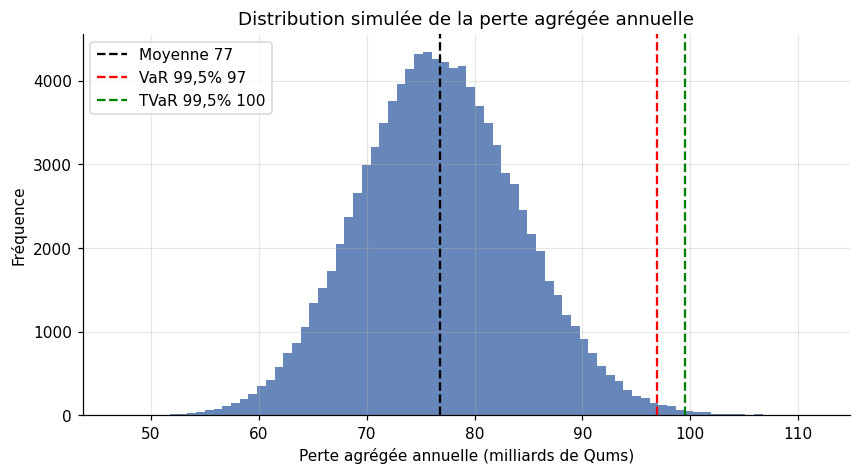

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(agg/1000, bins=80, color="#4C72B0", alpha=.85)
for v, c, l in [(mean_agg,"black","Moyenne"), (var995,"red","VaR 99,5%"), (tvar995,"green","TVaR 99,5%")]:
    ax.axvline(v/1000, color=c, ls="--", lw=1.5, label=f"{l} {v/1000:,.0f}")
ax.set_xlabel("Perte agrégée annuelle (milliards de Qums)"); ax.set_ylabel("Fréquence")
ax.set_title("Distribution simulée de la perte agrégée annuelle"); ax.legend(); plt.show()

## 5. Tarification commerciale

La prime commerciale ajoute à la prime pure :

* une **marge de risque** déterminée par un **coût du capital** de 6 % appliqué au capital
  économique, allouée à chaque barrage au prorata de sa contribution à la volatilité
  ($\text{LGF}_i\sqrt{p_i(1-p_i)}$) ;
* un **chargement de frais** de 10 % (gestion, acquisition) et une **contribution de 5 %**
  à un fonds de prévention.

$$ \text{Prime brute}_i = \frac{\text{EAL}_i + \text{marge}_i}{1 - 10\% - 5\%}. $$

Prime pure totale   : 76,800 Qm
Marge de risque     : 1,364 Qm
Prime brute totale  : 91,957 Qm  (chargement global 19.7%)


,prime_pure,prime_tech,prime_brute
classe,,,
A,1.837,1.880,2.211
B,2.681,2.735,3.218
C,3.601,3.667,4.315
D,4.151,4.223,4.968
E,7.566,7.684,9.040


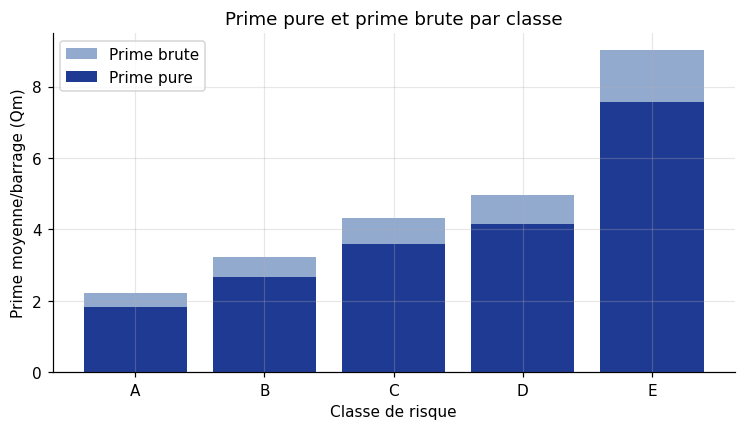

In [14]:
COC, EXPENSE, PREV_FUND = 0.06, 0.10, 0.05
risk_margin_total = COC * capital
contrib = sev * np.sqrt(p*(1-p)); alloc = contrib/contrib.sum()
df["risk_margin"] = risk_margin_total * alloc
df["prime_tech"]  = df["EAL"] + df["risk_margin"]
df["prime_brute"] = df["prime_tech"] / (1 - EXPENSE - PREV_FUND)

tot_pure, tot_brute = df["EAL"].sum(), df["prime_brute"].sum()
print(f"Prime pure totale   : {tot_pure:,.0f} Qm")
print(f"Marge de risque     : {risk_margin_total:,.0f} Qm")
print(f"Prime brute totale  : {tot_brute:,.0f} Qm  (chargement global {100*(tot_brute/tot_pure-1):.1f}%)")

clp = df.groupby("classe", observed=True).agg(
    prime_pure=("EAL","mean"), prime_tech=("prime_tech","mean"), prime_brute=("prime_brute","mean")).round(3)
display(clp)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(clp.index.astype(str), clp["prime_brute"], color="#4C72B0", alpha=.6, label="Prime brute")
ax.bar(clp.index.astype(str), clp["prime_pure"], color="#1f3a93", label="Prime pure")
ax.set_xlabel("Classe de risque"); ax.set_ylabel("Prime moyenne/barrage (Qm)")
ax.set_title("Prime pure et prime brute par classe"); ax.legend(); plt.show()

## 6. Hypothèses économiques

Les hypothèses d'inflation et de rendement financier s'appuient sur les séries historiques
fournies (1962–2024). On retient une inflation tendancielle (~moyenne 20 ans) et un
rendement d'investissement aligné sur le taux sans risque à 10 ans récent.

Inflation retenue        : 2.48%
Rendement investissement : 2.78%


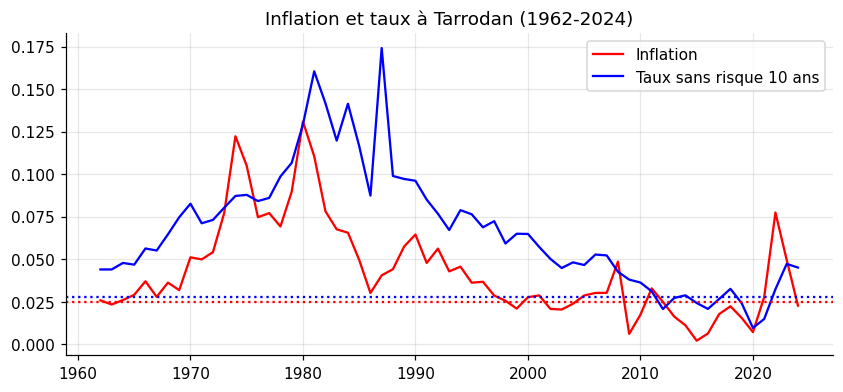

In [20]:
import openpyxl
wb = openpyxl.load_workbook(f"{DATA}/srcsc-2025-economic-data-summary.xlsx", data_only=True)
ws = wb["Inflation-Interest"]
er = [r for r in ws.iter_rows(values_only=True) if isinstance(r[0], int)]
yrs   = [r[0] for r in er]; infl = np.array([r[1] for r in er]); spot10 = np.array([r[4] for r in er])
INFL   = float(infl[-20:].mean())
IYIELD = float(spot10[-10:].mean())
print(f"Inflation retenue        : {INFL:.2%}")
print(f"Rendement investissement : {IYIELD:.2%}")

fig, ax = plt.subplots(figsize=(9,3.8))
ax.plot(yrs, infl, color="red", label="Inflation")
ax.plot(yrs, spot10, color="blue", label="Taux sans risque 10 ans")
ax.axhline(INFL, color="red", ls=":"); ax.axhline(IYIELD, color="blue", ls=":")
ax.set_title("Inflation et taux à Tarrodan (1962-2024)"); ax.legend(); plt.show()

## 7. Projection stochastique du fonds d'assurance (20 ans)

Le fonds est doté initialement du capital économique. Chaque année il encaisse les primes
(nettes de frais, indexées sur l'inflation), règle les sinistres simulés (coûts indexés sur
l'inflation) et capitalise son solde au rendement d'investissement. On simule 5 000
trajectoires et on mesure la **probabilité de ruine** (solde négatif au moins une fois).

Probabilité de ruine sur 20 ans : 0.42%
Fonds terminal - médiane 236,189 | P05 142,935 | P95 325,140 Qm


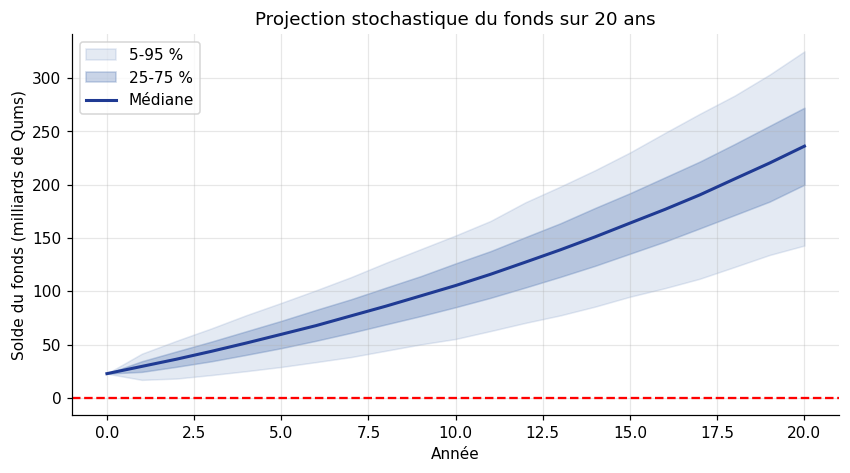

In [21]:
HORIZON, NPATH = 20, 5000
prime0 = tot_brute
claims = np.random.choice(agg, size=(NPATH, HORIZON), replace=True)
iff = (1+INFL)**np.arange(HORIZON)

fund = np.zeros((NPATH, HORIZON+1)); fund[:,0] = capital
ruin = np.zeros(NPATH, bool)
for t in range(HORIZON):
    fund[:,t+1] = fund[:,t]*(1+IYIELD) + prime0*iff[t]*(1-EXPENSE) - claims[:,t]*iff[t]
    ruin |= fund[:,t+1] < 0
term = fund[:,-1]
print(f"Probabilité de ruine sur {HORIZON} ans : {ruin.mean():.2%}")
print(f"Fonds terminal - médiane {np.median(term):,.0f} | P05 {np.quantile(term,.05):,.0f} | P95 {np.quantile(term,.95):,.0f} Qm")

fig, ax = plt.subplots(figsize=(9,4.5))
qs = np.quantile(fund, [.05,.25,.5,.75,.95], axis=0)/1000; xs=np.arange(HORIZON+1)
ax.fill_between(xs, qs[0], qs[4], color="#4C72B0", alpha=.15, label="5-95 %")
ax.fill_between(xs, qs[1], qs[3], color="#4C72B0", alpha=.30, label="25-75 %")
ax.plot(xs, qs[2], color="#1f3a93", lw=2, label="Médiane"); ax.axhline(0, color="red", ls="--")
ax.set_xlabel("Année"); ax.set_ylabel("Solde du fonds (milliards de Qums)")
ax.set_title("Projection stochastique du fonds sur 20 ans"); ax.legend(); plt.show()

## 8. Analyses de sensibilité

On teste la robustesse de la solvabilité du fonds à des variations des paramètres clés.

In [22]:
def proj_ruin(prime_mult=1, ret=IYIELD, infl=INFL, cap=capital, pof_mult=1, npath=3000):
    cl = np.random.choice(agg, size=(npath, HORIZON), replace=True)*pof_mult
    iff = (1+infl)**np.arange(HORIZON)
    f = np.full(npath, cap, float); r = np.zeros(npath, bool)
    for t in range(HORIZON):
        f = f*(1+ret) + prime0*prime_mult*iff[t]*(1-EXPENSE) - cl[:,t]*iff[t]
        r |= f < 0
    return 100*r.mean(), np.median(f)

scen = [("Base",{}), ("Prime -10%",{"prime_mult":.9}), ("Prime +10%",{"prime_mult":1.1}),
        ("Rendement 1,5%",{"ret":.015}), ("Rendement 4,5%",{"ret":.045}),
        ("Inflation 4%",{"infl":.04}), ("Sinistralité +20%",{"pof_mult":1.2}),
        ("Prévention -15% PoF",{"pof_mult":.85}), ("Capital initial /2",{"cap":capital/2})]
rows=[]
for lbl,kw in scen:
    pr,med = proj_ruin(**kw); rows.append({"Scénario":lbl,"Prob. ruine %":round(pr,2),"Fonds médian (Qm)":round(med)})
pd.DataFrame(rows)

,Scénario,Prob. ruine %,Fonds médian (Qm)
0,Base,0.37,233886
1,Prime -10%,82.83,-34387
2,Prime +10%,0.00,508012
3,"Rendement 1,5%",0.43,204634
4,"Rendement 4,5%",0.23,282685
5,Inflation 4%,0.47,263382
6,Sinistralité +20%,100.00,-268571
7,Prévention -15% PoF,0.00,613307
8,Capital initial /2,4.33,215224


Le fonds résiste bien dans le scénario central, mais reste **sensible à un sous-tarif**
(une prime inférieure de 10 % fait bondir la probabilité de ruine) et surtout à une
**dérive systématique de la sinistralité de +20 %**, qui rend la ruine quasi certaine. Ces
deux résultats motivent (i) une marge de prudence dans le tarif et (ii) un **traité de
réassurance** couvrant le risque de queue / corrélé.

## 9. Impact d'un programme national de prévention

Les données montrent que les ouvrages **régulés** et **bien évalués** ont une probabilité de
défaillance plus faible. On modélise un programme national (inspections, plans d'urgence,
réhabilitation des ouvrages anciens / mal notés) réduisant la probabilité annuelle de
défaillance de **20 %** sur les ouvrages à fort enjeu (*High*/*Significant*) et de **10 %**
sur les ouvrages mal ou non notés.

Prime pure : 76,800 -> 63,476 Qm  (17.3% de réduction)
Économie annuelle d'espérance de perte : 13,324 Qm


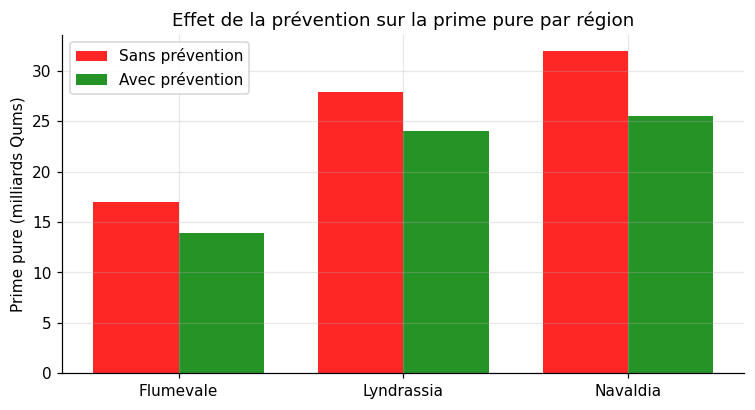

In [24]:
df["p_annual_prev"] = df["p_annual"]
df.loc[df["Hazard"].isin(["High","Significant"]), "p_annual_prev"] *= 0.80
df.loc[df["Assessment"].isin(["Poor","Unsatisfactory","Not Rated","Not Available"]), "p_annual_prev"] *= 0.90
df["EAL_prev"] = df["p_annual_prev"]*df["LGF_total"]
red = 1 - df["EAL_prev"].sum()/df["EAL"].sum()
print(f"Prime pure : {df['EAL'].sum():,.0f} -> {df['EAL_prev'].sum():,.0f} Qm  ({red:.1%} de réduction)")
print(f"Économie annuelle d'espérance de perte : {df['EAL'].sum()-df['EAL_prev'].sum():,.0f} Qm")

gr = df.groupby("Region").agg(av=("EAL","sum"), ap=("EAL_prev","sum"))/1000
x=np.arange(len(gr)); w=.38
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w/2, gr["av"], w, label="Sans prévention", color="red", alpha=.85)
ax.bar(x+w/2, gr["ap"], w, label="Avec prévention", color="green", alpha=.85)
ax.set_xticks(x); ax.set_xticklabels(gr.index); ax.set_ylabel("Prime pure (milliards Qums)")
ax.set_title("Effet de la prévention sur la prime pure par région"); ax.legend(); plt.show()

## 10. Synthèse

* **Portefeuille** : 19 368 barrages en terre ; exposition totale ≈ 7,6 millions de Qm ;
  perte attendue sur 10 ans ≈ 731 000 Qm.
* **Prime pure annuelle** ≈ 76 800 Qm ; **prime commerciale** ≈ 92 000 Qm (chargement global
  ≈ 20 %), différenciée en 5 classes de risque.
* **Capital économique** (TVaR 99,5 %) ≈ 22 700 Qm.
* **Soutenabilité** : avec dotation initiale au niveau du capital économique et tarif chargé,
  la probabilité de ruine sur 20 ans est < 0,5 % dans le scénario central.
* **Prévention** : un programme ciblé réduit l'espérance de perte de ~17 %, finançable par la
  contribution de 5 % intégrée au tarif.
* **Recommandations** : tarification par classe, fonds de prévention, et **réassurance** du
  risque extrême / corrélé pour absorber les scénarios de dérive de sinistralité.